Top 10 features by mean |SHAP|:
         feature  mean_abs_shap
   Accident_Type       0.460920
        Latitude       0.169328
     Cause_Group       0.147606
  Police_Station       0.104932
       Longitude       0.104663
         Road_Km       0.098599
            Hour       0.083353
         Road_ID       0.072190
Road_Delineation       0.070487
       Day_Phase       0.068080


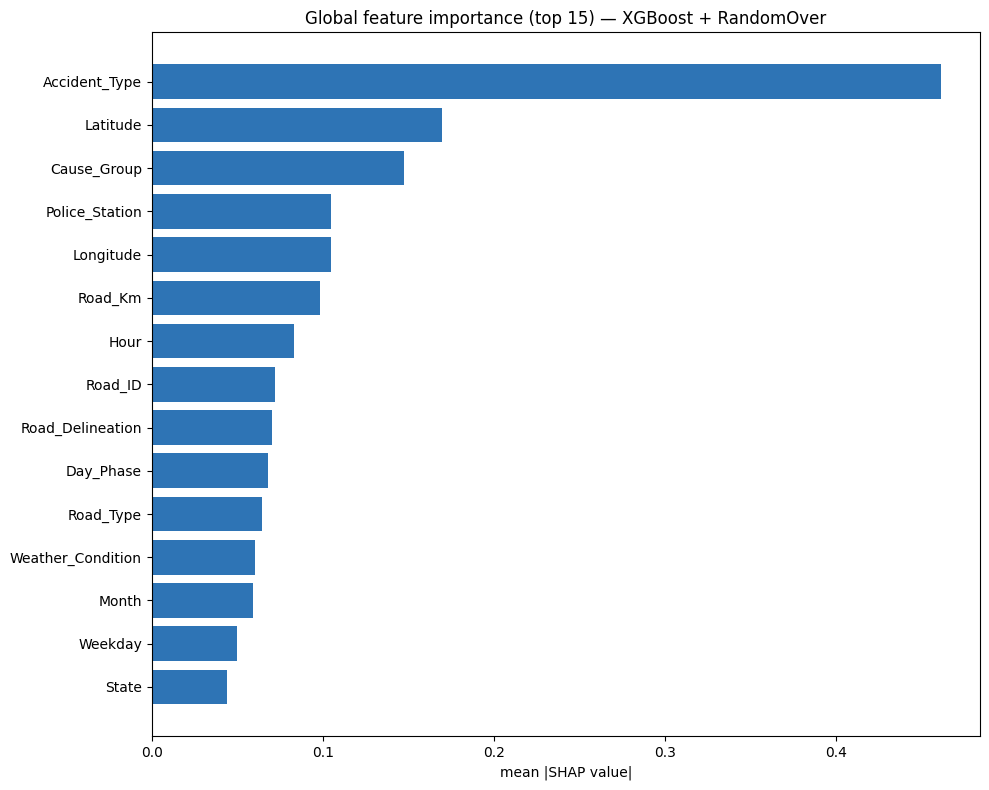

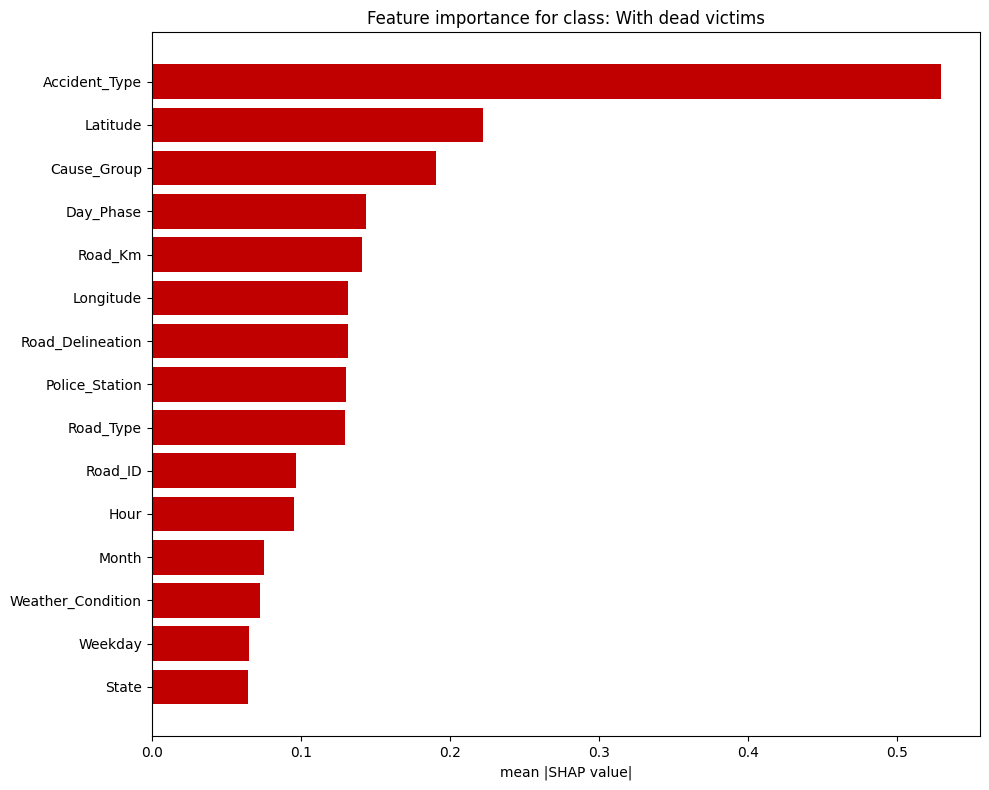

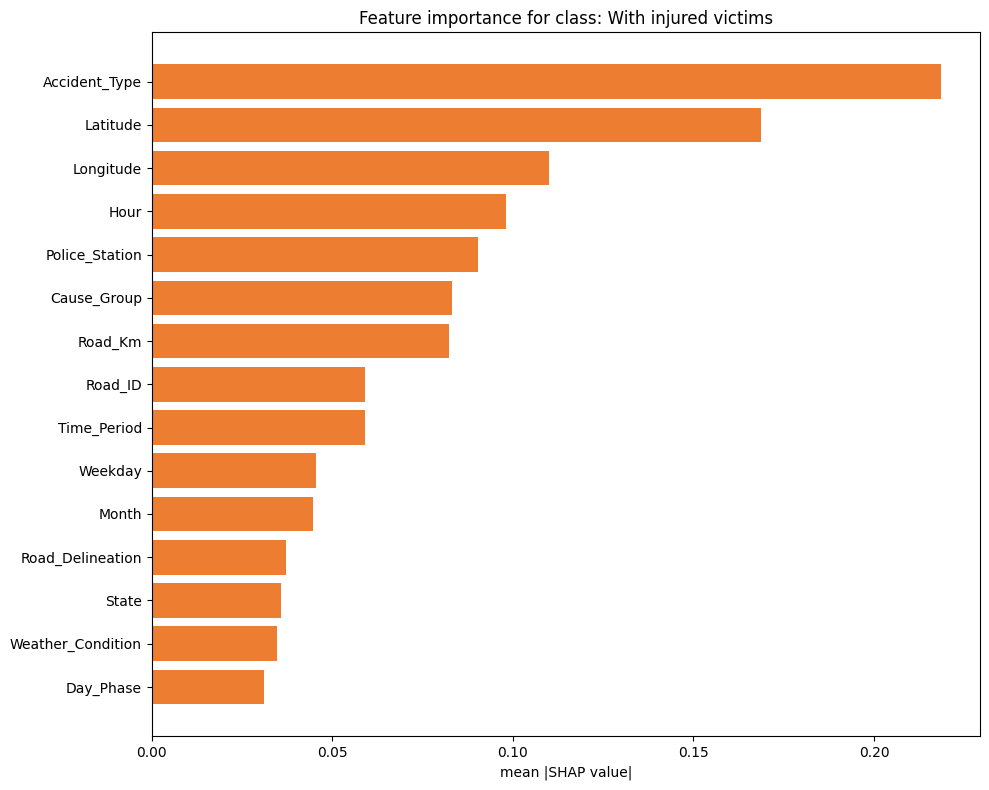

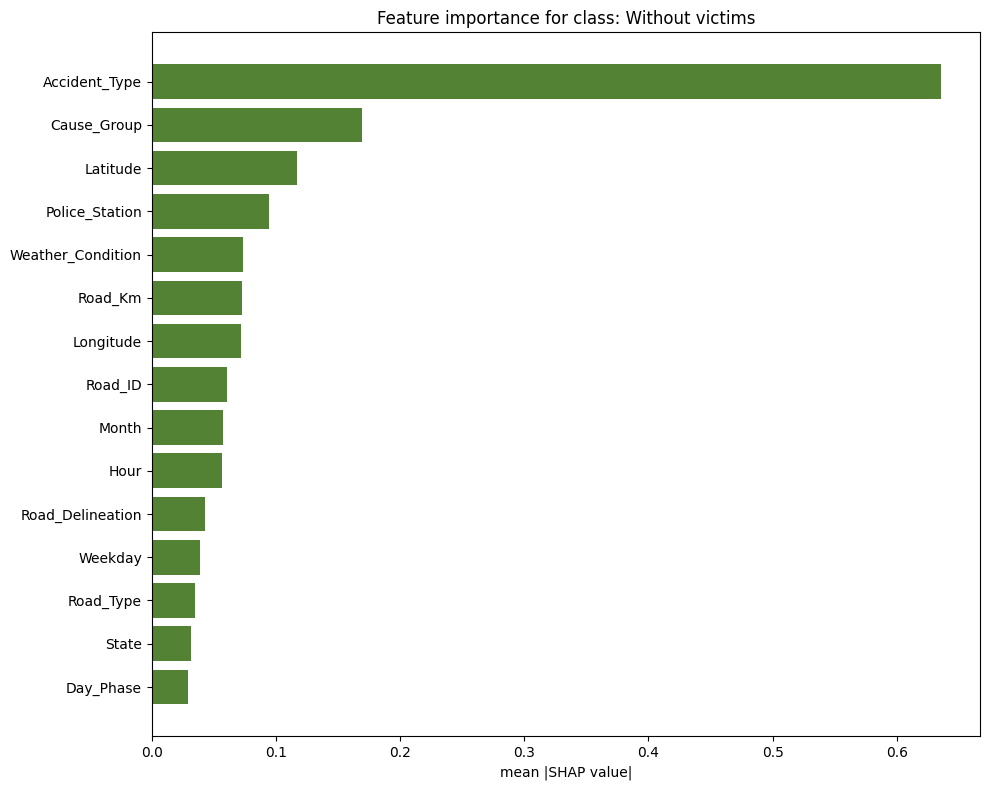

In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shap
from sklearn.model_selection import train_test_split

RANDOM_STATE = 25
DATA_DIR   = Path.cwd().parent / 'data' / 'processed'
MODELS_DIR = Path.cwd().parent / 'models'

pipe   = joblib.load(MODELS_DIR / 'phase4_best_XGBoost_RandomOver.joblib')
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['Victims_Condition']
y_train_full = pd.read_parquet(DATA_DIR / 'y_train.parquet')['Victims_Condition']
_, class_labels = pd.factorize(y_train_full, sort=True)
y_test_int = pd.Categorical(y_test, categories=class_labels).codes

preprocessor = pipe.named_steps['pre']
classifier   = pipe.named_steps['clf']
X_test_transformed = preprocessor.transform(X_test)
feature_names_ohe  = preprocessor.get_feature_names_out()

_, sample_idx = train_test_split(
    np.arange(len(y_test_int)),
    test_size=10_000, stratify=y_test_int, random_state=RANDOM_STATE,
)
X_sample = X_test_transformed[sample_idx]
y_sample = y_test_int[sample_idx]

explainer   = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)

def map_ohe_to_original(fname):
    if fname.startswith('num__'): return fname[5:]
    if fname.startswith('cat__'):
        parts = fname[5:].rsplit('_', 1)
        return parts[0] if len(parts) == 2 else fname[5:]
    return fname

original_names   = [map_ohe_to_original(f) for f in feature_names_ohe]
unique_originals = list(dict.fromkeys(original_names))

def aggregate_shap(shap_arr):
    agg = np.zeros((shap_arr.shape[0], len(unique_originals), shap_arr.shape[2]))
    for orig_idx, orig_name in enumerate(unique_originals):
        cols = [i for i, n in enumerate(original_names) if n == orig_name]
        agg[:, orig_idx, :] = shap_arr[:, cols, :].sum(axis=1)
    return agg

shap_agg = aggregate_shap(shap_values)  

# Global bar — now with 21 readable features
mean_abs = np.abs(shap_agg).mean(axis=(0, 2))
importance_df = pd.DataFrame({'feature': unique_originals, 'mean_abs_shap': mean_abs}) \
                  .sort_values('mean_abs_shap', ascending=False)
print("Top 10 features by mean |SHAP|:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top = importance_df.head(15).iloc[::-1]
ax.barh(top['feature'], top['mean_abs_shap'], color='#2E74B5')
ax.set_xlabel('mean |SHAP value|')
ax.set_title('Global feature importance (top 15) — XGBoost + RandomOver')
plt.tight_layout()
plt.show()

class_colors = ['#C00000', '#ED7D31', '#548235']
for cls_idx, cls_name in enumerate(class_labels):
    mean_abs_cls = np.abs(shap_agg[:, :, cls_idx]).mean(axis=0)
    df_cls = pd.DataFrame({'feature': unique_originals, 'mean_abs_shap': mean_abs_cls}) \
               .sort_values('mean_abs_shap', ascending=False).head(15).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(df_cls['feature'], df_cls['mean_abs_shap'], color=class_colors[cls_idx])
    ax.set_xlabel('mean |SHAP value|')
    ax.set_title(f'Feature importance for class: {cls_name}')
    plt.tight_layout()
    plt.show()